In [8]:

!mamba install pandas matplotlib
%pip install vaderSentiment
!mamba install seaborn

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.2969000000059605 seconds
All requested packages already installed.
mambajs 0.21.1

Process pip requirements ...

Requirement vaderSentiment already satisfied.
mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.6865 seconds
  Name          Version  Build                Channel
-------------------------------------------------------------------
+ patsy         1.0.2    py313h1804a44_3      emscripten-forge-4x
+ seaborn       0.13.2   hd8ed1ab_3           conda-forge
+ seaborn-base  0.13.2   pyhd8ed1ab_3         conda-forge
+ statsmodels   0.14.6   np23py313hd8db738_2  emscripten-forge-4x


Most common words in HIGH rated restaurants:
  indian: 75
  american: 47
  north: 47
  cafe: 38
  italian: 38
  food: 34
  desserts: 31
  continental: 31
  asian: 25
  chinese: 23

Most common words in LOW rated restaurants:
  indian: 1287
  north: 1107
  food: 740
  chinese: 682
  fast: 525
  mughlai: 253
  bakery: 225
  south: 180
  street: 175
  mithai: 142

Positive reviews (polarity > 0.5): 301
Negative reviews (polarity < -0.5): 0

Top words in Positive reviews:
  indian: 75
  american: 47
  north: 47
  cafe: 38
  italian: 38
  food: 34
  desserts: 31
  continental: 31
  asian: 25
  chinese: 23

Top words in Negative reviews:

Average review length across dataset: 19.91 characters


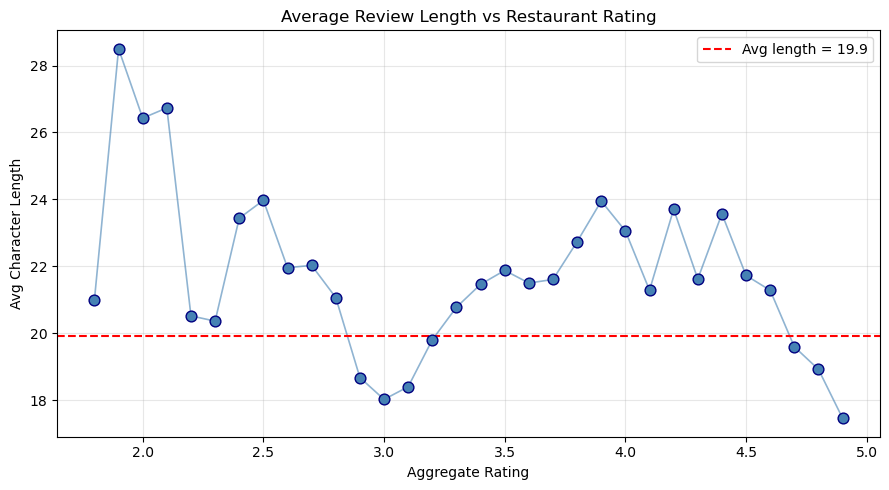

Plot saved as task1_length_vs_rating.png


In [6]:
#task1
import pandas as pd
import re
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
 
df = pd.read_csv("Dataset .csv", encoding='utf-8-sig')
 
# Step 1.1 - Text Preprocessing
df['Cuisines'] = df['Cuisines'].fillna('')
df['Cuisines'] = df['Cuisines'].str.lower()
df['Cuisines'] = df['Cuisines'].apply(lambda x: re.sub(r'[^a-z\s]', ' ', x))
 

# Step 1.2A - Frequency Based Keyword Extraction
high_rated = df[df['Aggregate rating'] >= 4.5]
low_rated  = df[df['Aggregate rating'] <= 2.5]
 
stop_words = {'the', 'and', 'is', 'in', 'of', 'a', 'to', 'with', 'for', 'an'}
 
def get_top_words(series, n=10):
    all_words = []
    for text in series:
        words = text.split()
        for w in words:
            w = w.strip()
            if w and w not in stop_words:
                all_words.append(w)
    return Counter(all_words).most_common(n)
 
high_keywords = get_top_words(high_rated['Cuisines'])
low_keywords  = get_top_words(low_rated['Cuisines'])
 
print("Most common words in HIGH rated restaurants:")
for word, count in high_keywords:
    print(f"  {word}: {count}")
 
print("\nMost common words in LOW rated restaurants:")
for word, count in low_keywords:
    print(f"  {word}: {count}")

# Step 1.2B - Sentiment Analysis using VADER


sia = SentimentIntensityAnalyzer()
 
df['polarity'] = df['Rating text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
 
pos_reviews = df[df['polarity'] > 0.5]
neg_reviews = df[df['polarity'] < -0.5]
 
print(f"\nPositive reviews (polarity > 0.5): {len(pos_reviews)}")
print(f"Negative reviews (polarity < -0.5): {len(neg_reviews)}")
 
pos_words = get_top_words(pos_reviews['Cuisines'])
neg_words  = get_top_words(neg_reviews['Cuisines'])
 
print("\nTop words in Positive reviews:")
for word, count in pos_words:
    print(f"  {word}: {count}")
 
print("\nTop words in Negative reviews:")
for word, count in neg_words:
    print(f"  {word}: {count}")

# Step 1.3 - Review Length vs Rating
 
df['review_length'] = df['Cuisines'].apply(lambda x: len(str(x)))
 
avg_length = df['review_length'].mean()
print(f"\nAverage review length across dataset: {avg_length:.2f} characters")

filtered = df[df['Aggregate rating'] > 0]
length_by_rating = filtered.groupby('Aggregate rating')['review_length'].mean().reset_index()
 
# scatter plot
plt.figure(figsize=(9, 5))
plt.scatter(length_by_rating['Aggregate rating'], length_by_rating['review_length'],
            color='steelblue', edgecolors='navy', s=60, zorder=3)
plt.plot(length_by_rating['Aggregate rating'], length_by_rating['review_length'],
         color='steelblue', linewidth=1.2, alpha=0.6)
plt.axhline(avg_length, color='red', linestyle='--', label=f'Avg length = {avg_length:.1f}')
plt.title('Average Review Length vs Restaurant Rating')
plt.xlabel('Aggregate Rating')
plt.ylabel('Avg Character Length')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task1_length_vs_rating.png', dpi=150)
plt.show()
print("Plot saved as task1_length_vs_rating.png")

Maximum votes: 10934
Minimum votes: 0

Restaurant(s) with most votes:
Restaurant Name  Votes  Aggregate rating
           Toit  10934               4.8

Number of restaurants with 0 votes: 1094

Pearson Correlation (Votes vs Aggregate Rating): 0.3137
Weak to moderate positive correlation


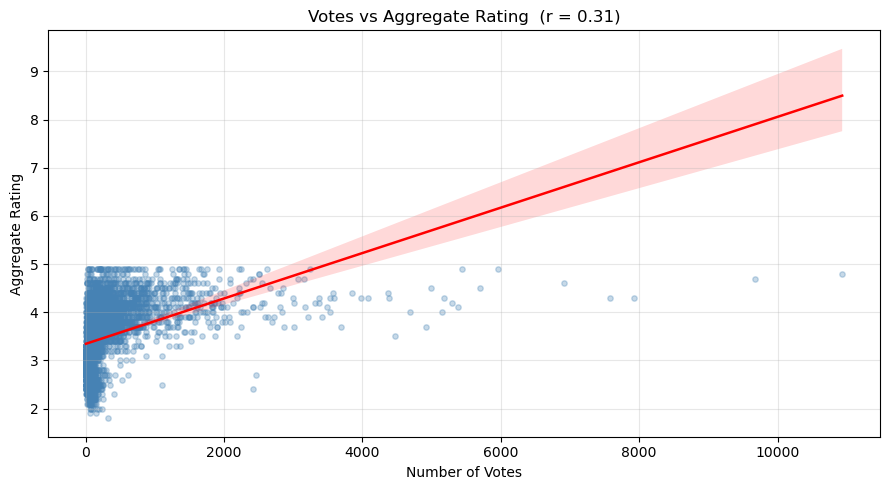

Plot saved as task2_votes_vs_rating.png


In [10]:
#task2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
df = pd.read_csv("Dataset .csv", encoding='utf-8-sig')

# Identify Extremes
max_votes = df['Votes'].max()
min_votes = df['Votes'].min()
 
print(f"Maximum votes: {max_votes}")
print(f"Minimum votes: {min_votes}")
 
highest_votes = df[df['Votes'] == df['Votes'].max()]
lowest_votes  = df[df['Votes'] == df['Votes'].min()]
 
print(f"\nRestaurant(s) with most votes:")
print(highest_votes[['Restaurant Name', 'Votes', 'Aggregate rating']].to_string(index=False))
 
print(f"\nNumber of restaurants with 0 votes: {len(lowest_votes)}")

# Correlation Analysis
 
correlation = df['Votes'].corr(df['Aggregate rating'])
print(f"\nPearson Correlation (Votes vs Aggregate Rating): {correlation:.4f}")
if correlation > 0.5:
    print("Strong positive correlation")
elif correlation > 0.2:
    print("Weak to moderate positive correlation")
else:
    print("Very weak or no correlation")
 
# scatter plot with regression line
plt.figure(figsize=(9, 5))
 
# only plotting restaurants that have been rated, 0 rating ones skew the plot
plot_df = df[df['Aggregate rating'] > 0]
 
sns.regplot(data=plot_df, x='Votes', y='Aggregate rating',
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 1.8},
            ci=95)
 
plt.title(f'Votes vs Aggregate Rating  (r = {correlation:.2f})')
plt.xlabel('Number of Votes')
plt.ylabel('Aggregate Rating')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task2_votes_vs_rating.png', dpi=150)
plt.show()
print("Plot saved as task2_votes_vs_rating.png")
 

Online Delivery availability by Price Range:
Price range
1    15.77
2    41.31
3    29.19
4     9.04
Name: has_online_delivery, dtype: float64

Table Booking availability by Price Range:
Price range
1     0.02
2     7.68
3    45.74
4    46.76
Name: has_table_booking, dtype: float64

Combined Summary:
             Online Delivery (%)  Table Booking (%)
Price range                                        
1                          15.77               0.02
2                          41.31               7.68
3                          29.19              45.74
4                           9.04              46.76

Analysis:
  Price 1 -> Online: 15.8%  Table: 0.0%
  Price 4 -> Online: 9.0%  Table: 46.8%


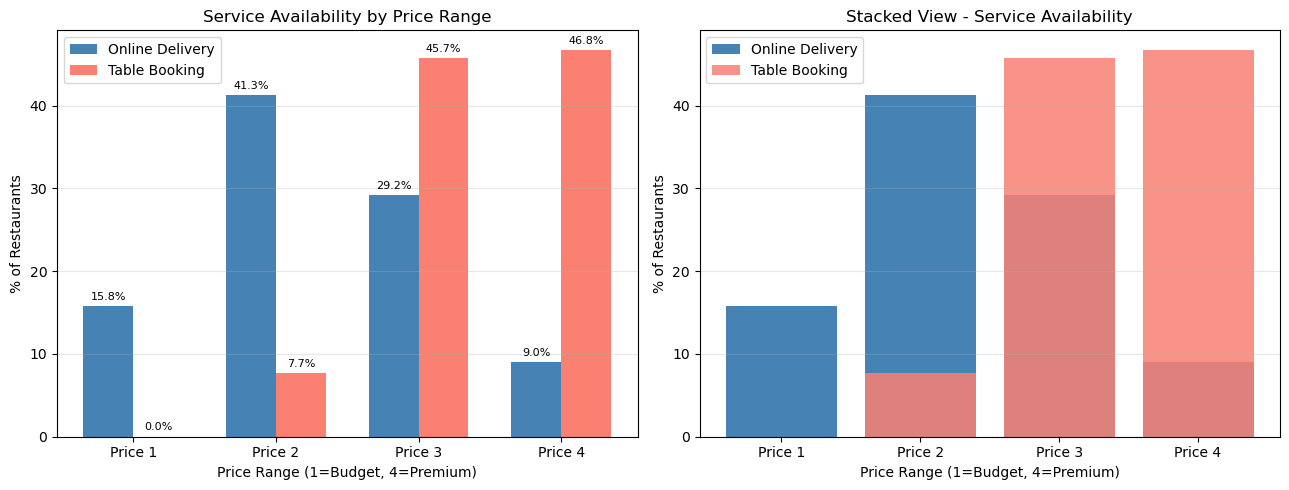

Plot saved as task3_price_vs_services.png


In [11]:
#task3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
 
df = pd.read_csv("Dataset .csv", encoding='utf-8-sig')
 
# Relationship Analysis
df['has_online_delivery'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})
df['has_table_booking']   = df['Has Table booking'].map({'Yes': 1, 'No': 0})
online_by_price = df.groupby('Price range')['has_online_delivery'].mean() * 100
table_by_price  = df.groupby('Price range')['has_table_booking'].mean() * 100
 
print("Online Delivery availability by Price Range:")
print(online_by_price.round(2))
 
print("\nTable Booking availability by Price Range:")
print(table_by_price.round(2))

# Determine Service Likelihood + Visualization
summary = pd.DataFrame({
    'Online Delivery (%)': online_by_price,
    'Table Booking (%)':   table_by_price
})
 
print("\nCombined Summary:")
print(summary.round(2))

print("\nAnalysis:")
print(f"  Price 1 -> Online: {online_by_price[1]:.1f}%  Table: {table_by_price[1]:.1f}%")
print(f"  Price 4 -> Online: {online_by_price[4]:.1f}%  Table: {table_by_price[4]:.1f}%")
 
# grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# grouped bar
x = np.arange(len(summary))
width = 0.35
 
bars1 = axes[0].bar(x - width/2, summary['Online Delivery (%)'], width,
                    label='Online Delivery', color='steelblue')
bars2 = axes[0].bar(x + width/2, summary['Table Booking (%)'],   width,
                    label='Table Booking',   color='salmon')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
 
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Price {i}' for i in summary.index])
axes[0].set_title('Service Availability by Price Range')
axes[0].set_ylabel('% of Restaurants')
axes[0].set_xlabel('Price Range (1=Budget, 4=Premium)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
 
# stacked bar
axes[1].bar(summary.index, summary['Online Delivery (%)'],
            label='Online Delivery', color='steelblue')
axes[1].bar(summary.index, summary['Table Booking (%)'],
            label='Table Booking',   color='salmon', alpha=0.85)
 
axes[1].set_title('Stacked View - Service Availability')
axes[1].set_ylabel('% of Restaurants')
axes[1].set_xlabel('Price Range (1=Budget, 4=Premium)')
axes[1].set_xticks(summary.index)
axes[1].set_xticklabels([f'Price {i}' for i in summary.index])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig('task3_price_vs_services.png', dpi=150)
plt.show()
print("Plot saved as task3_price_vs_services.png")